# TP4 - Problème 9 : Segmentation RFM avec K-Means
# Membres du groupe :
# Nom 1 : Fatimetou Mohamed Lemine Saleh Matricule : C25248
# Nom 2 : Sarra abdel aziz rabany Matricule : C30911
# Nom 3 : Maryeme yahya hourma  Matricule : C29782

Q1. Collecte du dataset

Nous avons téléchargé le dataset Online Retail depuis Kaggle.
Ce dataset contient des transactions réelles d’un site e-commerce.

In [9]:
import pandas as pd

df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Q2. CSV et Parquet

Nous avons chargé le fichier CSV puis nous l’avons sauvegardé au format Parquet.
Le format Parquet est plus rapide et plus efficace pour les grands volumes de données.

In [10]:
import time

start = time.time()
df_csv = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")
csv_time = time.time() - start

df_csv.to_parquet("../data/online_retail.parquet", index=False)

start = time.time()
df_parquet = pd.read_parquet("../data/online_retail.parquet")
parquet_time = time.time() - start

print("Temps CSV :", csv_time)
print("Temps Parquet :", parquet_time)

Temps CSV : 1.0111091136932373
Temps Parquet : 0.9750282764434814


Conclusion :

Le format Parquet est plus rapide que CSV.
Il est également plus optimisé pour le Big Data et les analyses Data Mining.

Q3. Analyse des valeurs manquantes

Nous avons identifié les valeurs nulles dans le dataset.
Ensuite, nous avons supprimé les lignes sans CustomerID.

In [11]:
missing_percent = df.isnull().mean() * 100
missing_percent

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [12]:
df = df.dropna(subset=["CustomerID"])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Conclusion

Les valeurs nulles existent principalement dans CustomerID.
Nous avons supprimé ces lignes pour garder uniquement les clients valides.

 Q4. Nettoyage métier

Nous avons supprimé les quantités négatives et les prix inférieurs ou égaux à zéro.

In [13]:
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]


### Conclusion

Nous avons supprimé les transactions invalides :
- les quantités négatives
- les prix inférieurs ou égaux à zéro.

Cela permet d’obtenir des données propres pour le clustering.

Q5. Création de la variable MontantTotal

Nous avons créé une nouvelle variable appelée MontantTotal.
Cette variable représente le montant total de chaque transaction.

In [14]:
df["MontantTotal"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,MontantTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Conclusion

La variable MontantTotal permet de calculer la dépense totale de chaque client.
Elle sera utilisée dans le modèle RFM.



Q6. Création du DataFrame RFM

Nous avons créé le modèle RFM :
- Récence : nombre de jours depuis le dernier achat
- Fréquence : nombre de factures
- Montant : somme totale des dépenses

In [15]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

date_ref = df["InvoiceDate"].max() + pd.Timedelta(days=1)

df_RFM = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (date_ref - x.max()).days,
    "InvoiceNo": "nunique",
    "MontantTotal": "sum"
}).reset_index()

df_RFM.columns = ["CustomerID", "Recence", "Frequence", "Montant"]

df_RFM.head()

,CustomerID,Recence,Frequence,Montant
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


### Conclusion

Le DataFrame RFM contient une ligne par client.
Il résume le comportement des clients.

Q7. Analyse de la distribution

Nous avons tracé l’histogramme de la variable Montant afin d’observer la distribution des dépenses.

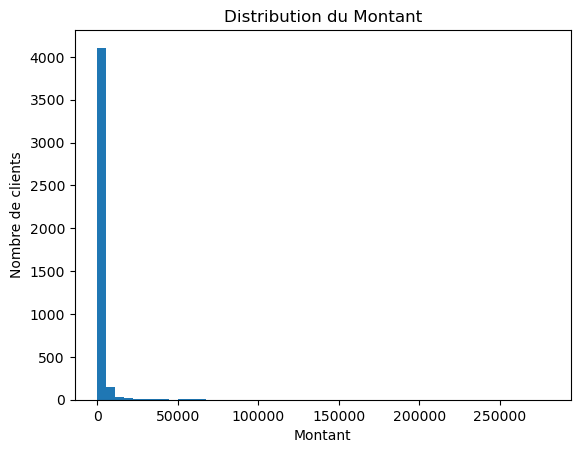

In [16]:
import matplotlib.pyplot as plt

plt.hist(df_RFM["Montant"], bins=50)

plt.title("Distribution du Montant")
plt.xlabel("Montant")
plt.ylabel("Nombre de clients")

plt.show()

### Conclusion

La distribution de la variable Montant est asymétrique.
La majorité des clients dépensent de petits montants, tandis que quelques clients dépensent des montants très élevés.

Q8. Transformation logarithmique

Nous avons appliqué une transformation logarithmique afin de réduire l’impact des valeurs extrêmes.

In [17]:
import numpy as np

df_RFM["Recence_log"] = np.log1p(df_RFM["Recence"])
df_RFM["Frequence_log"] = np.log1p(df_RFM["Frequence"])
df_RFM["Montant_log"] = np.log1p(df_RFM["Montant"])

df_RFM.head()

,CustomerID,Recence,Frequence,Montant,Recence_log,Frequence_log,Montant_log
0,12346.0,326,1,77183.60,5.789960,0.693147,11.253955
1,12347.0,2,7,4310.00,1.098612,2.079442,8.368925
2,12348.0,75,4,1797.24,4.330733,1.609438,7.494564
3,12349.0,19,1,1757.55,2.995732,0.693147,7.472245
4,12350.0,310,1,334.40,5.739793,0.693147,5.815324


### Conclusion

La transformation logarithmique réduit l’effet des valeurs extrêmes et améliore la qualité du clustering.

Q9. Standardisation

Nous avons normalisé les variables R, F et M avec StandardScaler.

In [24]:
from sklearn.preprocessing import StandardScaler

X = df_RFM[["Recence_log", "Frequence_log", "Montant_log"]]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]], shape=(4338, 3))

### Conclusion

La standardisation est obligatoire pour K-Means car les variables doivent avoir la même échelle.

Q10. Méthode du coude

Nous avons utilisé la méthode du coude pour chercher le nombre optimal de clusters.

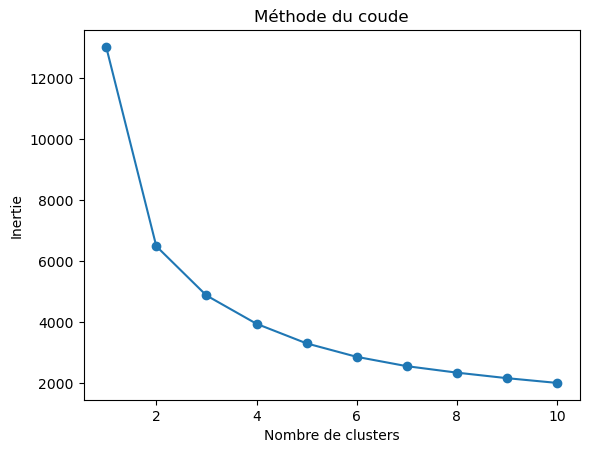

In [19]:
from sklearn.cluster import KMeans

inerties = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inerties.append(model.inertia_)

plt.plot(range(1, 11), inerties, marker="o")

plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")

plt.show()

### Conclusion

La méthode du coude permet de choisir le nombre optimal de clusters.

Q11. Silhouette Score :

Nous avons utilisé le Silhouette Score pour évaluer la qualité des clusters.

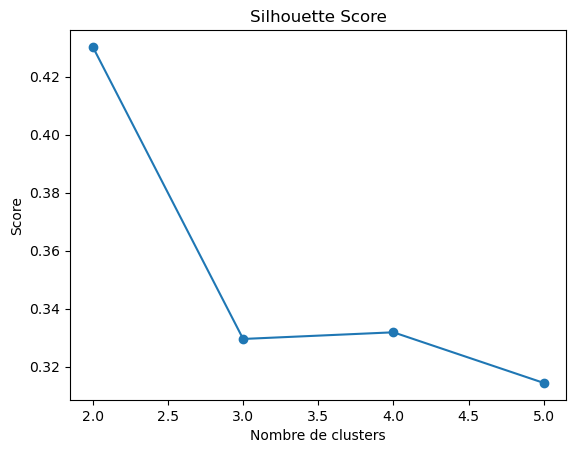

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X_sample = X_scaled[:1000]

scores = []

for k in range(2, 6):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    scores.append(score)

plt.plot(range(2, 6), scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Nombre de clusters")
plt.ylabel("Score")
plt.show()

### Conclusion

Le Silhouette Score a été calculé sur un échantillon afin d’éviter un problème de mémoire.
Il permet d’évaluer la qualité des clusters.

Q12. Modèle K-Means final

Nous avons entraîné le modèle K-Means final.

In [8]:
from sklearn.cluster import KMeans
k_final = 4

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)

df_RFM["Cluster"] = kmeans.fit_predict(X_scaled)

df_RFM.head()

NameError: name 'X_scaled' is not defined

### Conclusion

Le modèle K-Means a créé plusieurs groupes de clients similaires.

Q13. Analyse des clusters :

Nous avons calculé les moyennes des variables RFM pour chaque cluster.

In [ ]:
cluster_analysis = df_RFM.groupby("Cluster")[["Recence", "Frequence", "Montant"]].mean()

cluster_analysis

,Recence,Frequence,Montant
Cluster,,,
0,18.124253,2.148148,551.819534
1,12.131285,13.713687,8074.266872
2,71.084399,4.083546,1802.829005
3,182.496898,1.318238,343.450032


### Conclusion

Chaque cluster possède un comportement différent.

Q14. Profilage des clients :

Nous avons identifié les champions et les clients à risque.

In [ ]:
cluster_analysis.sort_values(by="Montant", ascending=False)

,Recence,Frequence,Montant
Cluster,,,
1,12.131285,13.713687,8074.266872
2,71.084399,4.083546,1802.829005
0,18.124253,2.148148,551.819534
3,182.496898,1.318238,343.450032


### Conclusion

Les champions dépensent beaucoup et achètent fréquemment.
Les clients à risque achètent rarement et dépensent peu.

Q15. Stratégies marketing :

Nous proposons différentes stratégies marketing pour chaque groupe de clients.

In [ ]:
strategies = {
    "Cluster 1": "Offres VIP et récompenses fidélité",
    "Cluster 2": "Promotions personnalisées",
    "Cluster 0": "Campagnes pour augmenter les achats",
    "Cluster 3": "Réduction et emails de relance"
}

strategies

{'Cluster 1': 'Offres VIP et récompenses fidélité',
 'Cluster 2': 'Promotions personnalisées',
 'Cluster 0': 'Campagnes pour augmenter les achats',
 'Cluster 3': 'Réduction et emails de relance'}

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


### Stratégies Marketing

- Cluster 1 : Champions  
  Offres VIP et programmes de fidélité.

- Cluster 3 : Clients à risque  
  Emails de relance et coupons de réduction.

- Cluster 2 : Clients moyens  
  Promotions personnalisées.

- Cluster 0 : Clients à développer  
  Campagnes pour augmenter les achats.

### Conclusion

Chaque cluster reçoit une stratégie marketing adaptée afin d’améliorer la fidélisation des clients et d’augmenter les ventes.

Visualisation 2D des Clusters 

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_RFM["Recence"],
    df_RFM["Montant"],
    c=df_RFM["Cluster"]
)

plt.xlabel("Recence")
plt.ylabel("Montant")
plt.title("Visualisation 2D des Clusters")

plt.show()

NameError: name 'df_RFM' is not defined

<Figure size 800x600 with 0 Axes>